In [8]:
# capstone project, week N

import numpy as np
import warnings
import matplotlib.pyplot as plt

from bayes_tools import (
    normalize, initial_bounds, validate_bounds_consistency,
    generate_next_point, ucb_acquisition,
    append_observations, compute_iteration_diagnostics,
    fit_gp, get_length_scales, loo_predictions,
    fit_y_scale, to_scaled_units, from_scaled_units,
    compare_kappa_proposals, print_kappa_comparison,
    backtest_acquisitions, print_backtest_summary,
)
from viz_tools import (
    plot_2d_bo, plot_bo_diagnostics, plot_loo_calibration, plot_kappa_sensitivity,
    plot_acquisition_backtest,
)


# Function 1

2D, exploratory 



In [9]:
X_initial = np.load("initial_data/function_1/initial_inputs.npy")
y_initial = np.load("initial_data/function_1/initial_outputs.npy")
n_initial = len(y_initial)
D = X_initial.shape[1]

# Once, at the very start of the capstone:
new_X = np.empty((0, D))
new_y = np.empty((0,))


## Update this once per week

Include the new X and y values from the previous week

In [10]:
new_X = np.array([
    [0.760601, 0.199726]
])

new_y = np.array([-3.77292444076289e-115])


## Build the full dataset (initial + everything collected so far)

In [11]:
X, y = append_observations(X_initial, y_initial, new_X, new_y)

print("X_initial shape:", X_initial.shape, "| y_initial shape:", y_initial.shape)
print("new_X shape:     ", new_X.shape, "| new_y shape:     ", new_y.shape)
print("combined X shape:", X.shape, "| combined y shape:", y.shape)

print("\nX range per dimension:")
print("  min:", X.min(axis=0))
print("  max:", X.max(axis=0))
print("y range:", y.min(), "to", y.max())

# X is known to never be negative (external info from earlier in the
# capstone) -- remove lower_limit=0.0 below if that turns out not to
# apply to this particular function.
bounds = initial_bounds(X_initial, pad_fraction=1.0, lower_limit=0.0)
validate_bounds_consistency(X, bounds)
print("\nBounds:\n", bounds)


X_initial shape: (10, 2) | y_initial shape: (10,)
new_X shape:      (1, 2) | new_y shape:      (1,)
combined X shape: (11, 2) | combined y shape: (11,)

X range per dimension:
  min: [0.08250725 0.07872278]
  max: [0.88388983 0.8798981 ]
y range: -0.0036060626443634764 to 7.710875114502849e-16

Bounds:
 [[0.         1.68527241]
 [0.         1.68107343]]


## Correct for y's scale

`y` values for this function range across dozens of orders of magnitude -- default acquisition hyperparameter (kappa) is tuned assuming roughly unit-scale targets. Without correcting for this, `kappa*sigma` is essentially meaningless relative to real differences in `y`. Everything below runs in scaled units; `from_scaled_units` converts back to real units only when printing/plotting.

In [12]:
y_scale = fit_y_scale(y)
y_scaled = to_scaled_units(y, y_scale)

print("y_scale:", y_scale)
print("raw y range:   ", y.min(), "to", y.max())
print("scaled y range:", y_scaled.min(), "to", y_scaled.max())


y_scale: 0.0010366701219489613
raw y range:    -0.0036060626443634764 to 7.710875114502849e-16
scaled y range: -3.4785054261851434 to 7.438118405502268e-13


## Backtest acquisition functions (using only data already collected)

Make sure that we are picking the right acquisition function - test on part of the existing data set and see how closely our fn + param would match it. 
Only checking on existing data so not able to test which produces a good new point but it does give me some hints.


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/si

      config |  mean regret |  median regret |  mean picked y
-------------------------------------------------------------
     max_var |    3.422e-13 |      2.445e-37 |      4.891e-39
     pi_xi01 |       0.4174 |      7.438e-13 |        -0.4174
     ei_xi01 |       0.4174 |      7.438e-13 |        -0.4174
      ucb_k1 |        0.487 |      7.438e-13 |         -0.487
      ucb_k5 |        0.487 |      7.438e-13 |         -0.487
     ucb_k12 |        0.487 |      7.438e-13 |         -0.487
     exploit |       0.8348 |      7.438e-13 |        -0.8348


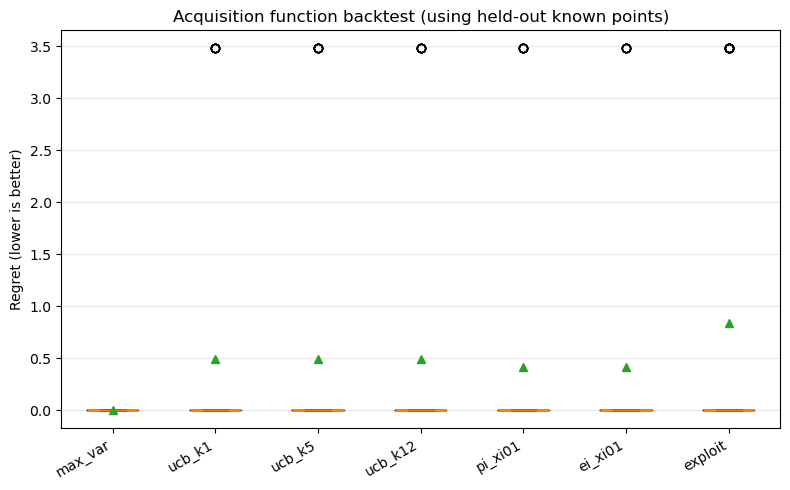

In [13]:
backtest_configs = [
    {"name": "ucb_k1",  "acquisition": "ucb", "kappa": 1.0},
    {"name": "ucb_k5",  "acquisition": "ucb", "kappa": 5.0},
    {"name": "ucb_k12", "acquisition": "ucb", "kappa": 12.0},
    {"name": "pi_xi01", "acquisition": "pi",  "xi": 0.01},
    {"name": "ei_xi01", "acquisition": "ei",  "xi": 0.01},
    {"name": "exploit", "acquisition": "exploit"},
    {"name": "max_var",  "acquisition": "max_variance"},
]

backtest_results = backtest_acquisitions(
    X, y_scaled, bounds, backtest_configs,
    n_repeats=50, seed_frac=0.5, maximize=True,
    gp_kwargs={"n_restarts_optimizer": 15}, random_state=0,
)
print_backtest_summary(backtest_results)

fig = plot_acquisition_backtest(backtest_results)
plt.show()


## Sensitivity check: which dimension matters more right now

Let's see which dimensions are making the most difference

In [14]:
gp_check = fit_gp(X, y_scaled, bounds, n_restarts_optimizer=20, random_state=0)
length_scales = get_length_scales(gp_check)
for dim, ls in sorted(enumerate(length_scales), key=lambda t: t[1]):
    tag = "(most sensitive)" if ls == length_scales.min() else ("(least sensitive)" if ls == length_scales.max() else "")
    print(f"x{dim}: length_scale = {ls:.3f} {tag}")


x0: length_scale = 0.010 (most sensitive)
x1: length_scale = 10.000 (least sensitive)


/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/nic.gibson/anaconda3/lib/python3.13/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


## Compare kappa values before committing

Cheap, no real evaluation spent: fits one GP and shows where different `kappa` values would propose to search *right now*. Read it by watching whether `x_next`/`distance_from_incumbent` keeps changing as `kappa` increases -- once proposals stop moving, exploration has saturated and larger values buy nothing.

Note `kappa` is dimensionless -- `mu` and `sigma` are both in `y`-units -- so it is unaffected by the y-scaling above. The rescale here matters for the backtest's PI/EI rows, not for UCB.

In [ ]:
kappa_rows = compare_kappa_proposals(X, y_scaled, bounds, kappa_values=[1.0, 3.0, 5.0, 8.0, 12.0],
                                      maximize=True, n_restarts=50, random_state=0)
print_kappa_comparison(kappa_rows)

fig = plot_kappa_sensitivity(X, y_scaled, bounds, gp_check, kappa_rows, ucb_acquisition, maximize=True)
plt.show()

# Committed choice -- reused by the proposal, the contour plot, and the
# diagnostics replay below, so they can't silently drift apart.
KAPPA = 3.0
print(f"\nusing kappa = {KAPPA}")

## Propose the next point

In [ ]:
x_next, gp = generate_next_point(
    X, y_scaled, bounds,
    acquisition="ucb",
    kappa=KAPPA,        # see the comparison above
    maximize=True,
    n_restarts=25,
    random_state=0,
)

print(f"\n--- Next point to evaluate (bounds shape {bounds.shape}) ---")
print("x_next:", np.round(x_next, 4))

mu_scaled, sigma_scaled = gp.predict(normalize(x_next.reshape(1, -1), bounds), return_std=True)
mu, sigma = from_scaled_units(mu_scaled, y_scale), from_scaled_units(sigma_scaled, y_scale)
print(f"GP predicted mean (real units): {mu[0]:.4g}, predicted std (real units): {sigma[0]:.4g}")

## Visualise the GP and acquisition function

In [ ]:
fig = plot_2d_bo(
    X, y_scaled, bounds, gp,
    acquisition_fn=ucb_acquisition,
    x_next=x_next,
    acq_kwargs={"kappa": KAPPA, "maximize": True},
    y_scale=y_scale,
)
plt.show()

## Sanity-check the surrogate model: leave-one-out calibration

Worth checking here given how extreme the y-scale is -- confirms the GP is actually learning something trustworthy rather than just fitting noise at this magnitude.

In [ ]:
pred_mean_scaled, pred_std_scaled = loo_predictions(X, y_scaled, bounds, gp_kwargs={"n_restarts_optimizer": 20})
fig = plot_loo_calibration(y_scaled, pred_mean_scaled, pred_std_scaled, y_scale=y_scale)
plt.show()


## Iteration diagnostics

IMPORTANT: replay with the SAME acquisition settings actually used above. That is enforced here by passing `KAPPA` rather than a hardcoded number -- replaying with different settings (a leftover `5.0`, or `pi`/`xi` from a template) reconstructs acquisition values that never applied to these proposals. This notebook previously had exactly that mismatch: `kappa=3.0` in the proposal, `5.0` here.

One caveat the constant can't fix: `compute_iteration_diagnostics` applies one setting to the *whole* history, so if any recorded observation was proposed under different settings its replayed acquisition value is still meaningless. The GP-hyperparameter and `domain_mean_std` columns are unaffected either way.

In [ ]:
history = compute_iteration_diagnostics(X, y_scaled, bounds, n_initial=n_initial,
                                         acquisition="ucb", kappa=KAPPA, maximize=True)
fig = plot_bo_diagnostics(history, bounds)
plt.show()

best_scaled = np.nanmax(history["y"])
print("Best y so far (real units):", from_scaled_units(best_scaled, y_scale))

## Raw diagnostic fields, in both units

In [ ]:
print("y (scaled):", history['y'])
print("y (real units):", from_scaled_units(history['y'], y_scale))


In [ ]:
print("acq_value (scaled units, NaN = initial batch):", history["acq_value"])


In [ ]:
# The proposal as a hyphen-separated string, for submission.
print("-".join(f"{v:.6f}" for v in x_next))

# Full precision as well. 6 dp is fine to submit, but paste THIS into next
# week's new_X: a 6-dp copy of function 4's proposal rounded 4e-7 outside its
# own upper bound and tripped validate_bounds_consistency.
print("\nfull precision (use for next week's new_X):")
print("-".join(repr(float(v)) for v in x_next))